In [1]:
832/(832+25)

0.970828471411902

In [ ]:
 #如果把不识别的W,U都看成*考虑都对的 正确率会更高, 错误的多半是bond原因，atom type预测都对了
1 - 8/(849+8)#charge as label,

In [1]:
import torch
# import detectron2

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
# print("Detectron2 version:", detectron2.__version__)


Torch version: 2.0.1
CUDA available: True


In [10]:
1- 20/(247+20), 1- 15/(247+20)

(0.9250936329588015, 0.9438202247191011)

In [ ]:

def count_tensor_differences(tensor_a, tensor_b):
    """
    统计两个张量在对应位置上的元素差异数量。

    参数：
    - tensor_a: 第一个张量
    - tensor_b: 第二个张量

    返回：
    - num_differences: 差异元素的数量
    - diff_indices: 差异元素的索引列表
    """
    # 检查两个张量的形状是否相同
    if tensor_a.shape != tensor_b.shape:
        raise ValueError("两个张量的形状不一致，无法比较。")
    # 比较两个张量，得到一个布尔张量，表示对应位置是否不同
    difference = tensor_a != tensor_b
    # 统计差异的数量
    num_differences = difference.sum().item()
    # 获取差异的索引位置
    diff_indices = torch.nonzero(difference, as_tuple=False).squeeze()
    return num_differences, diff_indices


In [2]:
8/(849+8)-1

-0.9906651108518086

In [4]:
import rdkit
from rdkit import Chem

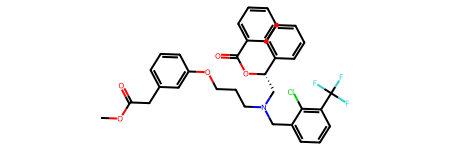

In [ ]:
#rdkit 画图的问题导致  红色重叠了 导致不相连的原子相连了，可以根据坐标去掉这类
Chem.MolFromSmiles("COC(=O)CC1=CC=CC(OCCCN(CC2=CC=CC(C(F)(F)F)=C2Cl)C[C@H](OC(=O)C2=CC=CC=C2)C2=CC=CC=C2)=C1")

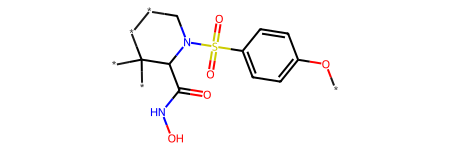

In [ ]:
Chem.MolFromSmiles("*Oc1ccc([S](=O)(=O)N2C**C(*)(*)C2C(=O)NO)cc1")#如果把不识别的W,U都看成*考虑都对的 正确率会更高

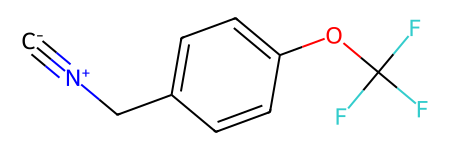

In [23]:
Chem.MolFromSmiles("[C-]#[N+]CC1=CC=C(OC(F)(F)F)C=C1")

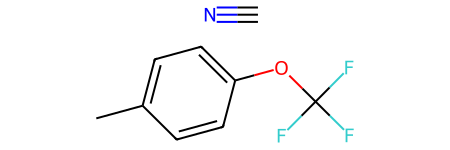

In [24]:
Chem.MolFromSmiles("C#N.Cc1ccc(OC(F)(F)F)cc1")

In [1]:
import pandas as pd

In [13]:
# 示例张量
tensor_a = torch.tensor([2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
                         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6],
                        )

tensor_b = torch.tensor([2, 4, 2, 2, 3, 2, 2, 2, 4, 3, 2, 8, 2, 2, 2, 2, 3, 2, 2, 2,
                         3, 2, 3, 2, 2, 2, 2, 2, 2, 8, 2, 2, 3, 2, 0, 0, 0, 0, 0, 0],
                        )

In [14]:
num_diffs, diff_indices = count_tensor_differences(tensor_a, tensor_b)


In [17]:
num_diffs/tensor_b.numel(),diff_indices

(0.375, tensor([ 4,  8,  9, 11, 16, 20, 22, 29, 32, 34, 35, 36, 37, 38, 39]))

In [ ]:
"""
charge_larged model
CLEF.csv,output_charge_CLEF.csv,847/(847+10),0.9883313885647608

"""
847/(847+10)

0.9883313885647608

In [2]:
import rdkit

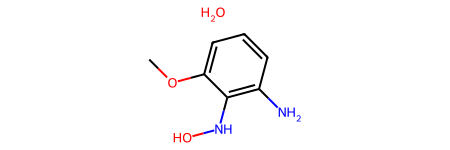

In [37]:
smi="COc1cccc(N)c1NO.O"#
# smi='CCCC[C@H](NC(=O)OC1(Cc2ccccc2)CCC1)C(=O)C(C#N)=[P@SP3](c1ccccc1)(c1ccccc1)c1ccccc1'
# smi="*C1=C(*)C(*)=C(C(*)(*)C(C)C)C(*)=C1*"
rdkit.Chem.MolFromSmiles(smi)

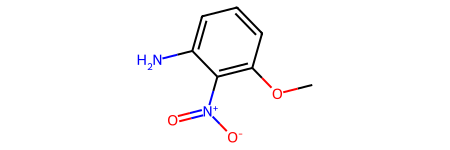

In [ ]:
smi='COC1=C([N+](=O)[O-])C(N)=CC=C1'
#US20050182067A1_p0032_x1638_y1021_c00113.png 基本识别正确 没组装好吗？？！
# smi="*C1=C(*)C(*)=C(C(*)(*)C(C)C)C(*)=C1*"
mol=rdkit.Chem.MolFromSmiles(smi)
mol

In [5]:
t1="COC(=O)CC1=CC=CC(OCCCN(CC2=CC=CC(C(F)(F)F)=C2Cl)C[C@H](OC(=O)C2=CC=CC=C2)C2=CC=CC=C2)=C1"
t2="C.C=C/C=C\C1=C/C(=C\C=C/C)C(=O)O[C@H]1CN(CCCOc1cccc(CC(=O)OC)c1)Cc1cccc(C(F)(F)F)c1Cl"

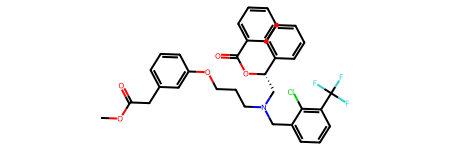

In [11]:
m1=rdkit.Chem.MolFromSmiles(t1)
m1

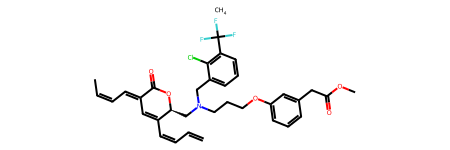

In [ ]:
m2=rdkit.Chem.MolFromSmiles(t2)#TODO may be bond predicted wrong
m2

In [13]:
m1.GetNumAtoms(),m2.GetNumAtoms()

(45, 45)

In [17]:
t1="[C-]#[N+]CC1=CN=CC=C1"
t2="C.NCc1cccnc1"
m1=rdkit.Chem.MolFromSmiles(t1)
m2=rdkit.Chem.MolFromSmiles(t2)


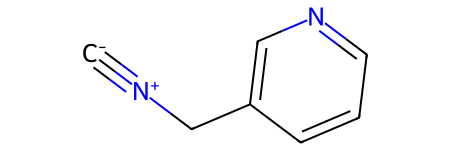

In [18]:
m1

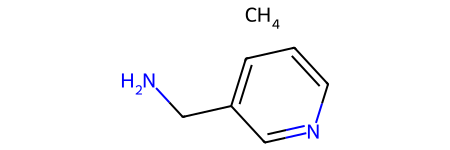

In [19]:
m2